# Task 2.1 Notebook 3: Evaluation and comparison

**Goal.** Check how well candidate genes separate disease and control (ROC / AUC), look at
pathways, and compare the statistics panel, the ML panel, and the official Midterm 1 panel.

**Survival analysis** from Rosati is not run. GSE75214 has no follow-up time.

**Discrimination** means telling disease from control. A downregulated gene can discriminate
well. High AUC in this notebook is **not** clinical validation.


## Key terms used in this notebook

| Term | Simple explanation |
| ---- | ------------------ |
| TP | True positive: disease sample called disease. |
| TN | True negative: control sample called control. |
| FP | False positive: control called disease. Extra tests and worry. |
| FN | False negative: disease called control. A case can be missed. |
| Sensitivity / Recall | TP / (TP + FN). How many true disease cases we detect. |
| Specificity | TN / (TN + FP). How many controls we correctly call control. |
| Precision | TP / (TP + FP). Among predicted disease, how many are true. |
| Threshold | Cut used to turn a score into disease vs control. Changing it trades FP vs FN. |
| ROC curve | Sensitivity vs false-positive rate across thresholds. |
| AUC | Area under the ROC. Larger means better discrimination **in this data**. |
| Cross-validation | Repeat train/test folds so one split does not drive the number. |
| Overfitting | The model looks strong on the same data used to choose genes. |
| Data leakage | Test information used during training or feature selection. |
| Optimistic estimate | Performance that is probably too high for a new hospital dataset. |
| LDA | Supervised method that finds a linear combination of numeric gene values that separates the classes. |
| Linear boundary | A straight decision cut in the transformed space. For two classes LDA has one direction (LD1). |
| Covariance | How numerical variables change together. LDA uses this structure. |
| Shrinkage LDA | A stable LDA version when there are many genes relative to samples (`lsqr` + `shrinkage='auto'`). |

```text
                    Actual
               Disease   Control
Pred Disease      TP        FP
Pred Control      FN        TN
```

Reducing FN improves sensitivity. Reducing FP improves specificity. We cannot always
minimise both at once. The ROC curve shows that trade-off.

**FDR is not the same as classifier FP.** FDR is for thousands of gene tests in DGE.
TP/FP/FN are for a classifier that predicts the sample class.


## 1. Setup and load every input

In [1]:
# We load the differential expression table, the DEG matrix, the machine learning panel,
# and the Midterm 1 breast cancer panel. All four are needed for the comparison.
import warnings
warnings.filterwarnings("ignore")
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RNG = 42

DATA = pathlib.Path("../01_Data")
OUT = pathlib.Path("../04_Analysis")
FIG = OUT / "figures"

dm = pd.read_csv(OUT / "deg_matrix_2_1.csv")
y = dm["target"].values
X = dm.drop(columns=["target"])
dge = pd.read_csv(OUT / "dge_table_2_1.csv", index_col=0)
ml = pd.read_csv(OUT / "ml_biomarkers_2_1.csv", index_col=0)
mt = pd.read_csv(DATA / "midterm1_biomarkers.csv")

from IPython.display import display

strong_deg = list(dge[(dge["FDR"] < 0.05) & (dge["log2FC"].abs() >= 1.5)].index)
ml_genes = list(ml.index)
mt_genes = list(mt["gene"])
print("Statistics panel (strong DEG, |log2FC|>=1.5):", len(strong_deg))
print("Machine learning panel:", len(ml_genes))
print("Midterm 1 panel (breast cancer):", len(mt_genes))

panel_inputs = pd.DataFrame({
    "Panel": [
        "Statistics (|log2FC|>=1.5, FDR<0.05)",
        "Machine learning consensus",
        "Midterm 1 (breast cancer)",
    ],
    "N genes": [len(strong_deg), len(ml_genes), len(mt_genes)],
    "Genes": [
        ", ".join(strong_deg[:20]) + (" ..." if len(strong_deg) > 20 else ""),
        ", ".join(ml_genes),
        ", ".join(mt_genes),
    ],
})
display(panel_inputs)

strong_deg_tbl = dge.loc[strong_deg, ["log2FC", "FDR", "direction"]].sort_values("log2FC", ascending=False)
print(f"\nStatistics panel — all {len(strong_deg)} genes:")
display(strong_deg_tbl.round(4))
print("Machine learning panel — all genes:")
display(ml.round(4))
print("Midterm 1 panel — official 8 genes:")
display(mt)

Statistics panel (strong DEG, |log2FC|>=1.5): 158
Machine learning panel: 16
Midterm 1 panel (breast cancer): 8


,Panel,N genes,Genes
0,"Statistics (|log2FC|>=1.5, FDR<0.05)",158,"ABCA12, ABCB1, ABCG2, ACSF2, ACSL4, ADGRL4, AN..."
1,Machine learning consensus,16,"IFITM3, CNTFR, PDZK1IP1, BACE2, SLC6A14, STXBP..."
2,Midterm 1 (breast cancer),8,"AC083967.1, AC108477.1, AC112777.1, AL356275.1..."



Statistics panel — all 158 genes:


,log2FC,FDR,direction
gene,,,
SLC6A14,4.5331,0.0000,up
DUOX2,4.0973,0.0000,up
MMP3,3.5576,0.0000,up
DUOXA2,3.3827,0.0000,up
MMP1,3.2628,0.0000,up
...,...,...,...
UGT2A3,-2.5901,0.0000,down
CYP2B6,-2.6850,0.0000,down
ABCG2,-2.7745,0.0000,down


Machine learning panel — all genes:


,log2FC,FDR,direction,n_methods,MI,RFECV,ElasticNet,GBC
gene,,,,,,,,
IFITM3,1.2432,0.0000,up,3,True,False,True,True
CNTFR,-1.9839,0.0000,down,3,True,False,True,True
PDZK1IP1,1.6307,0.0000,up,3,True,False,True,True
BACE2,1.3638,0.0000,up,3,True,True,True,False
SLC6A14,4.5331,0.0000,up,3,True,False,True,True
STXBP1,1.0620,0.0000,up,3,False,True,True,True
PAQR5,-1.9605,0.0000,down,2,True,False,False,True
SLC38A4,-1.5309,0.0000,down,2,True,False,True,False
TIMP1,2.1728,0.0000,up,2,True,False,False,True


Midterm 1 panel — official 8 genes:


,gene,log2FC,FDR,direction
0,AC083967.1,1.847025,2.987640e-48,upregulated
1,AC108477.1,-1.300579,6.429126e-56,downregulated
2,AC112777.1,1.292002,3.104111e-44,upregulated
3,AL356275.1,-1.779803,1.483020e-38,downregulated
4,ARHGAP16P,3.774969,2.644274e-63,upregulated
5,CST4,3.131563,5.774181e-103,upregulated
6,SLC6A2,-1.292690,3.446369e-107,downregulated
7,TRPM3,-1.036046,3.349964e-61,downregulated


Three lists: strong DEGs (|log2FC| >= 1.5), the ML consensus panel, and the
8 Midterm 1 genes. Midterm 1 is only a reference from another disease.


## 2. ROC for single genes

A ROC curve shows the trade-off between sensitivity and the false-positive rate when we
change the threshold. AUC summarises how well one gene separates the two classes in
**this** dataset.


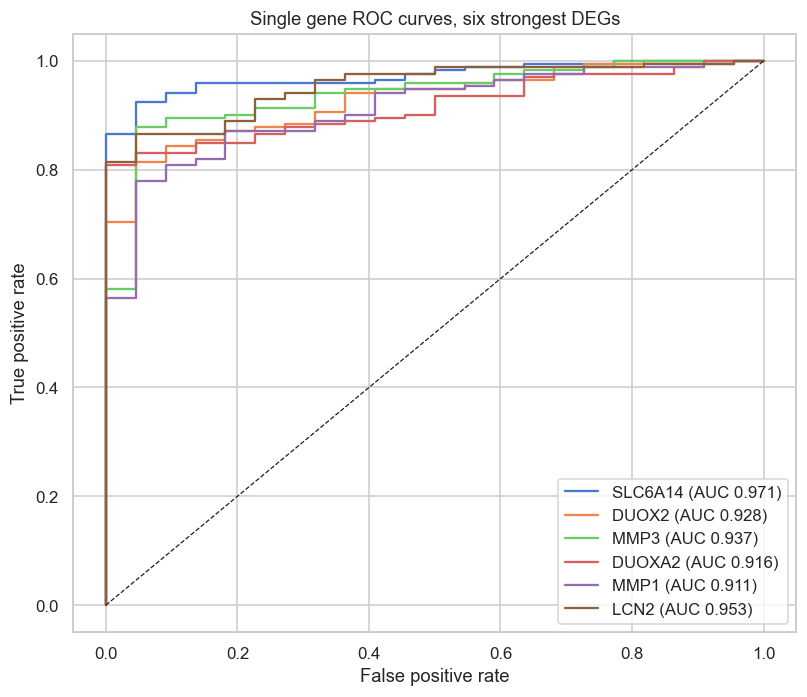

  SLC6A14    AUC 0.971
  DUOX2      AUC 0.928
  MMP3       AUC 0.937
  DUOXA2     AUC 0.916
  MMP1       AUC 0.911
  LCN2       AUC 0.953


In [2]:
# Rosati uses ROC to ask how well one biomarker separates the two groups. AUC of 1 is a
# perfect split and 0.5 is a coin flip. We compute the single gene AUC for the six
# strongest DEGs and draw their ROC curves.
def single_gene_auc(gene):
    """AUC of one gene used on its own to separate disease from control."""
    auc = roc_auc_score(y, X[gene].values)
    return max(auc, 1 - auc)

top6 = dge[dge["DEG"]].reindex(dge[dge["DEG"]]["log2FC"].abs().sort_values(ascending=False).index).head(6).index.tolist()
plt.figure(figsize=(7.5, 6.5))
for gene in top6:
    score = X[gene].values
    if roc_auc_score(y, score) < 0.5:
        score = -score
    fpr, tpr, _ = roc_curve(y, score)
    plt.plot(fpr, tpr, label=f"{gene} (AUC {single_gene_auc(gene):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Single gene ROC curves, six strongest DEGs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "task2_1_roc_single.png", dpi=150)
plt.show()
for gene in top6:
    print(f"  {gene:10s} AUC {single_gene_auc(gene):.3f}")

Several inflammation-related genes have single-gene AUC above 0.91 here.
That is strong discriminatory **potential** in GSE75214. Independent validation is still
required. High AUC does not mean a ready clinical test.


## 3. ROC for gene panels (several models)

We already compare **one** LDA, logistic regression and random forest. We do not add a second
LDA analysis.

**Why LDA is a reasonable baseline here.** Gene-expression values are numeric. LDA gives a
simple linear baseline. Numeric data alone do not prove LDA is always correct. LDA assumes
class-specific multivariate distributions and a similar covariance structure. Feature selection
already reduces the number of genes, and we use shrinkage LDA so the covariance is more stable.

Scaling sits **inside** the CV pipeline. SMOTE sits **inside** each training fold only.


In [3]:
from IPython.display import display
# Compare LDA (simple linear baseline) with logistic regression and random forest.
# SMOTE is inside each CV fold. The test fold never sees synthetic samples.
def panel_cv_auc(genes, estimator):
    """Five fold AUC of a classifier on a gene panel, with SMOTE inside each fold."""
    pipe = ImbPipeline([("smote", SMOTE(random_state=RNG)),
                        ("scale", StandardScaler()),
                        ("clf", estimator)])
    scores = cross_val_score(pipe, X[genes].values, y,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
                             scoring="roc_auc")
    return scores.mean(), scores.std()

models = [
    ("LDA (linear baseline)", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ("Logistic Regression", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG)),
    ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RNG)),
]
rows = []
for pname, genes in [(f"Statistics panel ({len(strong_deg)})", strong_deg), (f"Machine learning panel ({len(ml_genes)})", ml_genes)]:
    for mname, est in models:
        mean, std = panel_cv_auc(genes, est)
        note = "linear baseline, shrinkage" if "LDA" in mname else ("linear, class weight" if "Logistic" in mname else "trees, class weight")
        rows.append({"panel": pname, "model": mname, "Mean CV AUC": round(mean, 4), "SD AUC": round(std, 4), "Notes": note})
panel_auc = pd.DataFrame(rows)
display(panel_auc)
panel_auc.to_csv(OUT / "panel_cv_auc_2_1.csv", index=False)
print(f"Saved: {OUT / 'panel_cv_auc_2_1.csv'}")


,panel,model,Mean CV AUC,SD AUC,Notes
0,Statistics panel (158),LDA (linear baseline),0.9821,0.0323,"linear baseline, shrinkage"
1,Statistics panel (158),Logistic Regression,0.9942,0.0071,"linear, class weight"
2,Statistics panel (158),Random Forest,0.9832,0.0086,"trees, class weight"
3,Machine learning panel (16),LDA (linear baseline),0.9948,0.0052,"linear baseline, shrinkage"
4,Machine learning panel (16),Logistic Regression,0.9948,0.0064,"linear, class weight"
5,Machine learning panel (16),Random Forest,0.9907,0.0077,"trees, class weight"


Saved: ..\04_Analysis\panel_cv_auc_2_1.csv


## WELM / BWELM (reuse from teamwork)

Weighted ELM and boosted WELM are imbalance-aware ELMs reused from teamwork.
Here they are compared with LDA / logistic regression / random forest on the **ML panel**,
using the same 80/20 stratified split as feature selection (`RNG=42`, test_size=0.20).
Features are standardized on the training split only.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
from welm_models import WELM, BWELM

X_ml = X[ml_genes].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ml, y, test_size=0.20, stratify=y, random_state=RNG,
)
scaler_w = StandardScaler()
X_tr_s = scaler_w.fit_transform(X_tr)
X_te_s = scaler_w.transform(X_te)

def welm_metrics(name, model):
    pred = model.predict(X_te_s)
    prob = model.predict_proba(X_te_s)[:, 1]
    return {
        "model": name,
        "Accuracy": round(accuracy_score(y_te, pred), 4),
        "Precision": round(precision_score(y_te, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, pred, zero_division=0), 4),
        "F1": round(f1_score(y_te, pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_te, prob), 4),
        "confusion_matrix": str(confusion_matrix(y_te, pred).tolist()),
    }

welm = WELM(n_hidden=200, C=1.0, random_state=RNG)
welm.fit(X_tr_s, y_tr)
bwelm = BWELM(n_estimators=5, n_hidden=200, C=1.0, random_state=RNG)
bwelm.fit(X_tr_s, y_tr)

welm_rows = [
    welm_metrics("WELM", welm),
    welm_metrics("BWELM", bwelm),
]
welm_tbl = pd.DataFrame(welm_rows)
display(welm_tbl)
welm_tbl.to_csv(OUT / "welm_bwelm_results_2_1.csv", index=False)
print(f"Saved: {OUT / 'welm_bwelm_results_2_1.csv'}")

# Hold-out metrics for LDA / LR / RF on ML panel (same 80/20 split; SMOTE on train only)
holdout_sklearn = []
sk_models = [
    ("LDA (linear baseline)", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ("Logistic Regression", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG)),
    ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RNG)),
]
for mname, est in sk_models:
    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=RNG)),
        ("scale", StandardScaler()),
        ("clf", est),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    prob = pipe.predict_proba(X_te)[:, 1]
    holdout_sklearn.append({
        "panel": f"Machine learning panel ({len(ml_genes)})",
        "model": mname,
        "evaluation": "80/20 hold-out (SMOTE on train)",
        "ROC-AUC": round(roc_auc_score(y_te, prob), 4),
        "SD": np.nan,
        "Accuracy": round(accuracy_score(y_te, pred), 4),
        "Precision": round(precision_score(y_te, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, pred, zero_division=0), 4),
        "F1": round(f1_score(y_te, pred, zero_division=0), 4),
        "Notes": "same split as WELM; linear baseline shrinkage for LDA",
    })
holdout_sklearn_df = pd.DataFrame(holdout_sklearn)
display(holdout_sklearn_df)
holdout_sklearn_df.to_csv(OUT / "ml_panel_holdout_2_1.csv", index=False)

# Unified summary for 2_0 overview (CV + hold-out)
cv_rows = panel_auc.rename(columns={"Mean CV AUC": "ROC-AUC", "SD AUC": "SD"}).assign(
    evaluation="5-fold CV (SMOTE inside folds)",
)
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    cv_rows[col] = np.nan
welm_rows_u = welm_tbl.assign(
    panel=f"Machine learning panel ({len(ml_genes)})",
    evaluation="80/20 hold-out",
    SD=np.nan,
    Notes="imbalance-aware ELM (teamwork reuse)",
)
cols = ["panel", "model", "evaluation", "ROC-AUC", "SD", "Accuracy", "Precision", "Recall", "F1", "Notes"]
unified = pd.concat([cv_rows[cols], welm_rows_u[cols], holdout_sklearn_df[cols]], ignore_index=True)
display(unified.round(4))
unified.to_csv(OUT / "model_comparison_summary_2_1.csv", index=False)
print(f"Saved: {OUT / 'model_comparison_summary_2_1.csv'}")


,model,Accuracy,Precision,Recall,F1,ROC-AUC,confusion_matrix
0,WELM,0.8974,1.0,0.8857,0.9394,0.9857,"[[4, 0], [4, 31]]"
1,BWELM,0.8974,1.0,0.8857,0.9394,0.9357,"[[4, 0], [4, 31]]"


Saved: ..\04_Analysis\welm_bwelm_results_2_1.csv


,panel,model,evaluation,ROC-AUC,SD,Accuracy,Precision,Recall,F1,Notes
0,Machine learning panel (16),LDA (linear baseline),80/20 hold-out (SMOTE on train),0.9714,NaN,0.8974,1.0,0.8857,0.9394,same split as WELM; linear baseline shrinkage ...
1,Machine learning panel (16),Logistic Regression,80/20 hold-out (SMOTE on train),0.9857,NaN,0.9487,1.0,0.9429,0.9706,same split as WELM; linear baseline shrinkage ...
2,Machine learning panel (16),Random Forest,80/20 hold-out (SMOTE on train),1.0000,NaN,0.9744,1.0,0.9714,0.9855,same split as WELM; linear baseline shrinkage ...


,panel,model,evaluation,ROC-AUC,SD,Accuracy,Precision,Recall,F1,Notes
0,Statistics panel (158),LDA (linear baseline),5-fold CV (SMOTE inside folds),0.9821,0.0323,NaN,NaN,NaN,NaN,"linear baseline, shrinkage"
1,Statistics panel (158),Logistic Regression,5-fold CV (SMOTE inside folds),0.9942,0.0071,NaN,NaN,NaN,NaN,"linear, class weight"
2,Statistics panel (158),Random Forest,5-fold CV (SMOTE inside folds),0.9832,0.0086,NaN,NaN,NaN,NaN,"trees, class weight"
3,Machine learning panel (16),LDA (linear baseline),5-fold CV (SMOTE inside folds),0.9948,0.0052,NaN,NaN,NaN,NaN,"linear baseline, shrinkage"
4,Machine learning panel (16),Logistic Regression,5-fold CV (SMOTE inside folds),0.9948,0.0064,NaN,NaN,NaN,NaN,"linear, class weight"
5,Machine learning panel (16),Random Forest,5-fold CV (SMOTE inside folds),0.9907,0.0077,NaN,NaN,NaN,NaN,"trees, class weight"
6,Machine learning panel (16),WELM,80/20 hold-out,0.9857,NaN,0.8974,1.0,0.8857,0.9394,imbalance-aware ELM (teamwork reuse)
7,Machine learning panel (16),BWELM,80/20 hold-out,0.9357,NaN,0.8974,1.0,0.8857,0.9394,imbalance-aware ELM (teamwork reuse)
8,Machine learning panel (16),LDA (linear baseline),80/20 hold-out (SMOTE on train),0.9714,NaN,0.8974,1.0,0.8857,0.9394,same split as WELM; linear baseline shrinkage ...
9,Machine learning panel (16),Logistic Regression,80/20 hold-out (SMOTE on train),0.9857,NaN,0.9487,1.0,0.9429,0.9706,same split as WELM; linear baseline shrinkage ...


Saved: ..\04_Analysis\model_comparison_summary_2_1.csv


Look at the table: LDA is the simple numeric baseline. Logistic regression and
random forest are extra checks. If all models have very high AUC, the groups are easy to
separate **in this dataset**. That result can be optimistic because genes were selected on
the same cohort. Independent validation is required before any clinical claim.


## Optional: first LDA axis (LD1)

For two classes, LDA has **one** discriminant direction. The plot below is a picture of that
axis on the ML panel. It is not a second model comparison and it is not a 2D LDA.


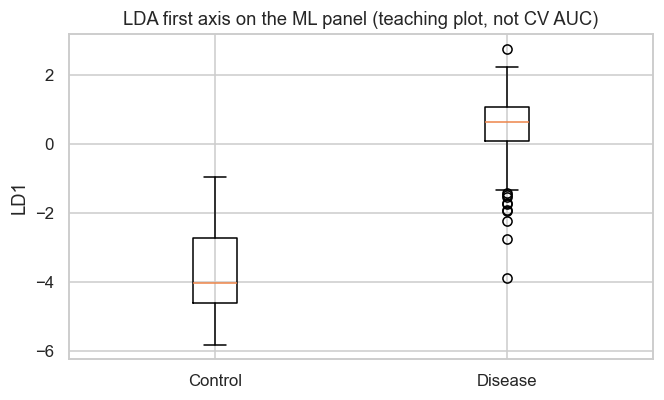

LD1 is one numeric score per sample. Separation here can look strong because the
same cohort was used to select genes. Use the CV table for the performance number.
CV still uses shrinkage LDA with solver=lsqr inside ImbPipeline + SMOTE.


In [5]:
# Same genes as the ML panel. Fitted on all samples only for a teaching picture.
# Official AUC still comes from the CV table above, not from this plot.
# lsqr LDA (used in CV) has no transform(); eigen is used here only to draw LD1.
from sklearn.pipeline import Pipeline as SkPipeline
lda_vis = SkPipeline([
    ("scale", StandardScaler()),
    ("clf", LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto")),
])
lda_vis.fit(X[ml_genes].values, y)
ld1 = lda_vis.transform(X[ml_genes].values)[:, 0]
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.boxplot([ld1[y == 0], ld1[y == 1]], tick_labels=["Control", "Disease"])
ax.set_ylabel("LD1")
ax.set_title("LDA first axis on the ML panel (teaching plot, not CV AUC)")
fig.tight_layout()
fig.savefig(FIG / "task2_1_lda_ld1.png", dpi=150)
plt.show()
print("LD1 is one numeric score per sample. Separation here can look strong because the")
print("same cohort was used to select genes. Use the CV table for the performance number.")
print("CV still uses shrinkage LDA with solver=lsqr inside ImbPipeline + SMOTE.")


If the two boxes sit apart, LDA found a linear direction that tracks the labels
in this dataset. That does not prove a clinical test. The CV AUC remains the number to quote.


## 4. Pathway enrichment analysis (Rosati section 3)

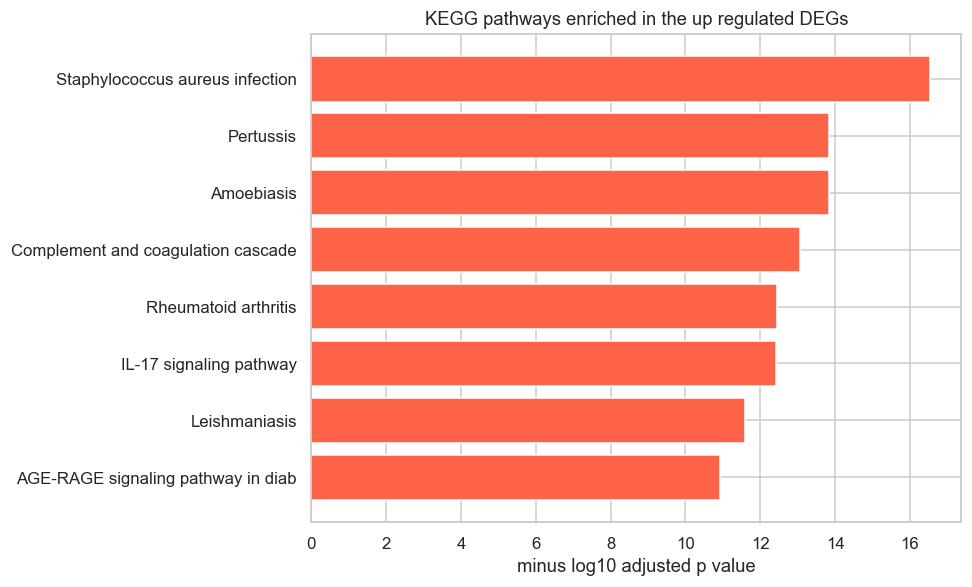

Top KEGG pathways (up genes):


,term,adj_pval,n_genes
0,Staphylococcus aureus infection,2.841961e-17,22
1,Pertussis,1.463069e-14,18
2,Amoebiasis,1.463069e-14,20
3,Complement and coagulation cascades,8.523968e-14,18
4,Rheumatoid arthritis,3.663646e-13,18
5,IL-17 signaling pathway,3.721527e-13,18
6,Leishmaniasis,2.561891e-12,16
7,AGE-RAGE signaling pathway in diabetic complic...,1.215442e-11,17
8,Cytokine-cytokine receptor interaction,5.979772e-11,26
9,TNF signaling pathway,6.597727e-11,17


Top GO biological processes (up genes):


,term,adj_pval,n_genes
0,cytokine-mediated signaling pathway (GO:0019221),3.070361e-26,60
1,extracellular matrix organization (GO:0030198),2.869002e-23,41
2,extracellular structure organization (GO:0043062),2.869002e-23,36
3,external encapsulating structure organization ...,2.869002e-23,36
4,cellular response to cytokine stimulus (GO:007...,1.632135e-22,49
5,inflammatory response (GO:0006954),2.733980e-19,33
6,granulocyte chemotaxis (GO:0071621),4.978070e-17,20
7,neutrophil migration (GO:1990266),3.143519e-15,19
8,neutrophil chemotaxis (GO:0030593),9.124912e-15,18
9,response to lipopolysaccharide (GO:0032496),2.620315e-13,23


In [6]:
# Enrichment turns a gene list into biology. We send the up regulated DEGs to Enrichr and
# read the top KEGG pathways and GO terms. We try the live service first and fall back to
# the cached tables so the notebook always runs.
def load_enrichr(tag, genes=None, library=None):
    """Return an enrichment table, live from Enrichr if possible, else from cache."""
    try:
        import requests
        r = requests.post("https://maayanlab.cloud/Enrichr/addList",
                          files={"list": (None, "\n".join(genes)), "description": (None, "x")}, timeout=30)
        uid = r.json()["userListId"]
        g = requests.get(f"https://maayanlab.cloud/Enrichr/enrich?userListId={uid}&backgroundType={library}", timeout=30).json()[library]
        return pd.DataFrame([{"term": x[1], "adj_pval": x[6], "n_genes": len(x[5])} for x in g[:10]])
    except Exception:
        return pd.read_csv(DATA / f"enrichr_{tag}.csv")[["term", "adj_pval", "n_genes"]]

up = dge[dge["DEG"] & (dge["direction"] == "up")].index.tolist()
kegg_up = load_enrichr("kegg_up", up, "KEGG_2021_Human")
go_up = load_enrichr("go_up", up, "GO_Biological_Process_2021")

from IPython.display import display

plt.figure(figsize=(9, 5.5))
top = kegg_up.head(8).iloc[::-1]
plt.barh(top["term"].str[:34], -np.log10(top["adj_pval"]), color="tomato")
plt.xlabel("minus log10 adjusted p value")
plt.title("KEGG pathways enriched in the up regulated DEGs")
plt.tight_layout()
plt.savefig(FIG / "task2_1_enrichment.png", dpi=150)
plt.show()
print("Top KEGG pathways (up genes):")
display(kegg_up.head(10))
print("Top GO biological processes (up genes):")
display(go_up.head(10))

Upregulated DEGs are enriched in immune / inflammation pathways in this run
(for example IL-17 related terms). Enrichment supports a biological story. It does not
prove that every gene in the list is a biomarker.


## 5. Compare the three panels

In [7]:
# The final question of Task 2.1 is how the approaches compare. We measure the overlap
# between the statistics panel, the machine learning panel, and the Midterm 1 panel, and
# note how many Midterm 1 genes even exist in this dataset.
from task2_1_lib import save_and_show

deg_set, ml_set, mt_set = set(strong_deg), set(ml_genes), set(mt_genes)
comparison = pd.DataFrame([
    {"comparison": "Machine learning within statistics panel", "shared": len(ml_set & deg_set), "out_of": len(ml_set)},
    {"comparison": "Machine learning within Midterm 1 panel", "shared": len(ml_set & mt_set), "out_of": len(ml_set)},
    {"comparison": "Statistics within Midterm 1 panel", "shared": len(deg_set & mt_set), "out_of": len(mt_set)},
    {"comparison": "Midterm 1 genes present in GSE75214", "shared": len(mt_set & set(dge.index)), "out_of": len(mt_set)},
])
save_and_show(comparison, OUT / "panel_comparison_2_1.csv", index=False, title="Panel overlap summary:")

shared_ml_deg = sorted(ml_set & deg_set)
shared_tbl = pd.DataFrame({"gene": shared_ml_deg})
if shared_ml_deg:
    shared_tbl = dge.loc[shared_ml_deg, ["log2FC", "FDR", "direction"]].reset_index()
    shared_tbl.columns = ["Gene", "log2FC", "FDR", "direction"]
print("Genes in both statistics and ML panels:")
display(shared_tbl.round(4))

print("Midterm 1 genes that are strong DEGs in IBD:", sorted(deg_set & mt_set))

Panel overlap summary:


,comparison,shared,out_of
0,Machine learning within statistics panel,6,16
1,Machine learning within Midterm 1 panel,0,16
2,Statistics within Midterm 1 panel,0,8
3,Midterm 1 genes present in GSE75214,3,8


Saved: ..\04_Analysis\panel_comparison_2_1.csv
Genes in both statistics and ML panels:


,Gene,log2FC,FDR,direction
0,CNTFR,-1.9839,0.0,down
1,PAQR5,-1.9605,0.0,down
2,PDZK1IP1,1.6307,0.0,up
3,SLC38A4,-1.5309,0.0,down
4,SLC6A14,4.5331,0.0,up
5,TIMP1,2.1728,0.0,up


Midterm 1 genes that are strong DEGs in IBD: []


The GSE75214 statistics panel and the ML panel share some genes. The official
8-gene Midterm 1 breast-cancer panel has **0** genes in common with the IBD ML panel.
Limited transfer is expected: the Midterm panel was built for another disease. This does
**not** mean the Midterm model was wrong.


## Limitations

GSE75214 has only 22 controls, so class balance is extreme. Feature selection and
evaluation use the same main dataset, so a very high AUC can be optimistic. Independent
validation is still needed. Survival data are not available for this GEO series. LDA,
logistic regression and random forest are compared as baselines, not as a claim of a
clinical diagnostic test.

## Notebook 3 summary

Single genes and small panels can separate IBD vs control in GSE75214 with high AUC.
SMOTE stays inside CV. LDA is the linear baseline. The Midterm 1 overlap is zero.

Oral-defense questions are consolidated in `2_0_final_overview.ipynb` (section **Oral defense**).
